# Simulação de placa térmica:
### Estudo da transferência de calor por condução em uma placa bidimensional, utilizando discretização numérica do domínio.

In [ ]:
# Importações!!!

import sys
import os
import importlib

root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root not in sys.path:
    sys.path.insert(0, root)

import thermal
importlib.reload(thermal)
import env
importlib.reload(env)
config = env.CONFIG_T

##### O sistema térmico foi implementado a partir de uma classe base capaz de resolver o problema tanto via fatoração de Cholesky quanto utilizando matrizes esparsas da biblioteca scipy, conforme orientado no enunciado.

In [ ]:
placa_termica_cholesky = thermal.Thermal(config = config, method = "cholesky")
placa_termica_cholesky.run(print_info=True, plot=True)

In [ ]:
placa_termica_sparse = thermal.Thermal(config = config, method = "sparse")
placa_termica_sparse.run(print_info=True, plot=True)

##### O primeiro estudo analisa a complexidade computacional dos métodos de Cholesky e sparse para diferentes níveis de discretização. Os testes foram realizados em dois computadores distintos para reduzir a influência do ambiente, e os resultados obtidos são apresentados a seguir:

![Resultados analise_complex_cholesky_vs_sparse para um computador](resultados_p1/tempos_medidos.png)


![Resultados analise_complex_cholesky_vs_sparse para outro computador](resultados_p1/tempos_medidos2.png)

##### As malhas geradas pela implementação estão de acordo com o esperado para as discretizações propostas:

In [ ]:
analise_complex_cholesky_vs_sparse = thermal.Thermal_P1(config = config, method = "sparse")
analise_complex_cholesky_vs_sparse.run(plot = True)

##### O terceiro estudo considera uma condutividade térmica variável, definida como uma função trigonométrica da posição na placa, e investiga seu impacto na distribuição de temperatura.

Resultados para classe: Thermal_P2
Resolvido por: sparse
Raio do círculo: 0.002 m
Temperatura no círculo: 30 °C


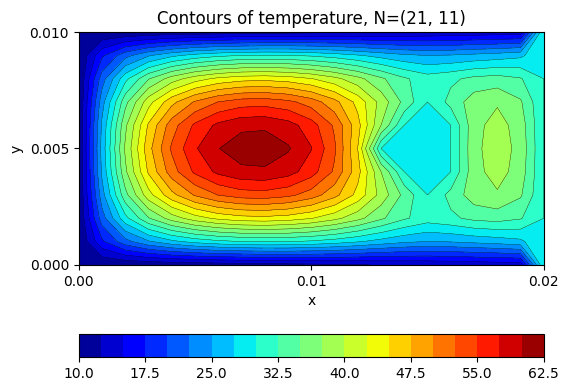

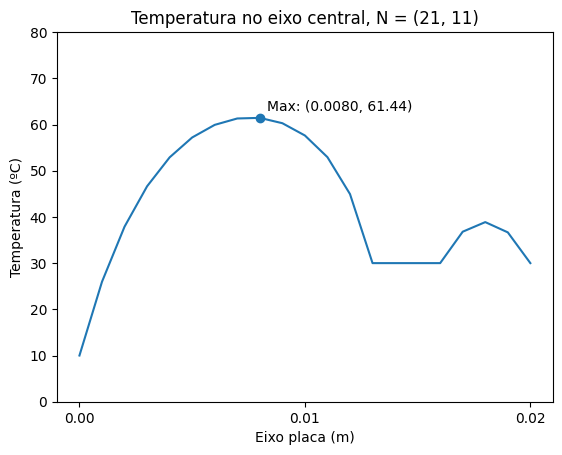

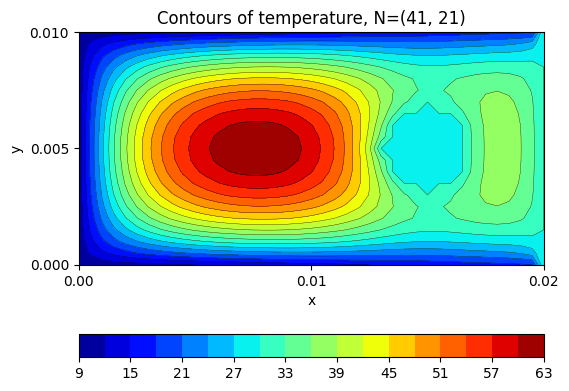

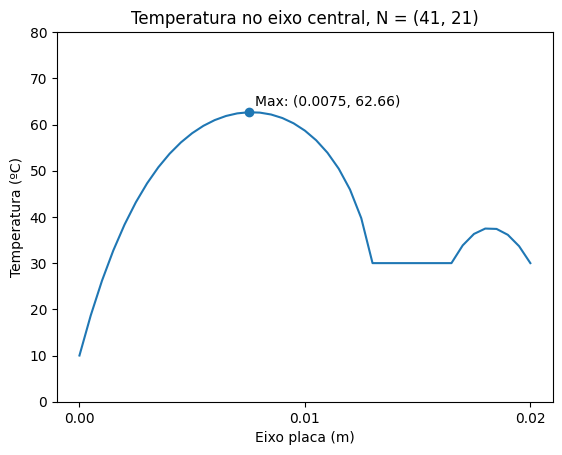

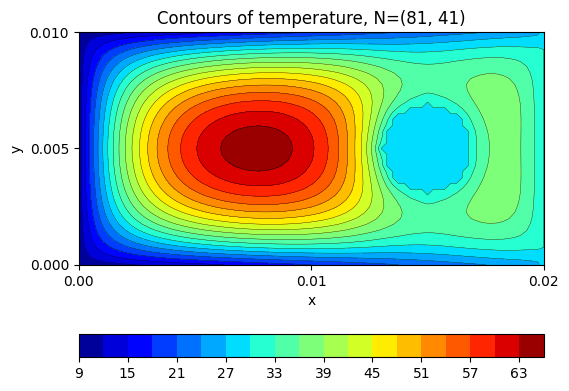

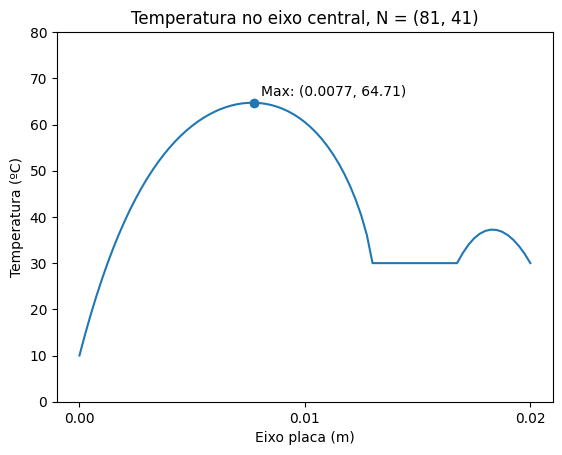

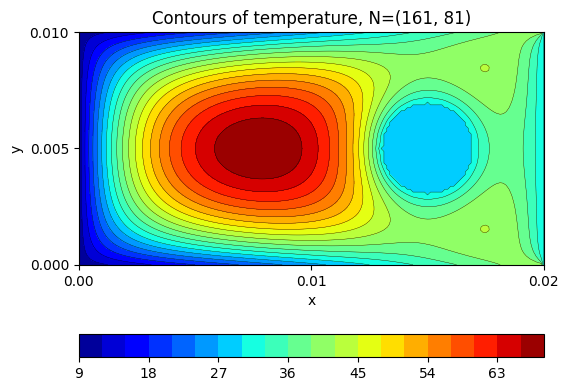

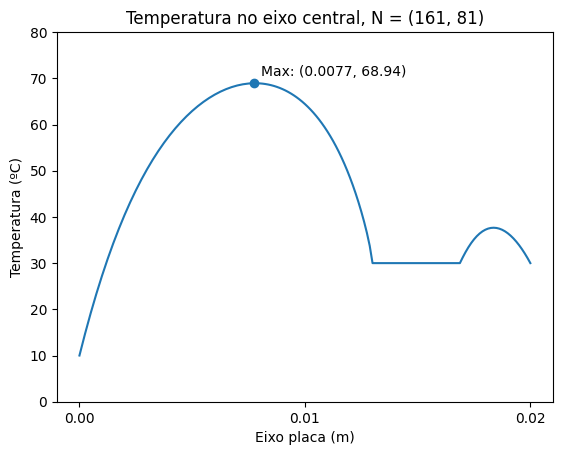

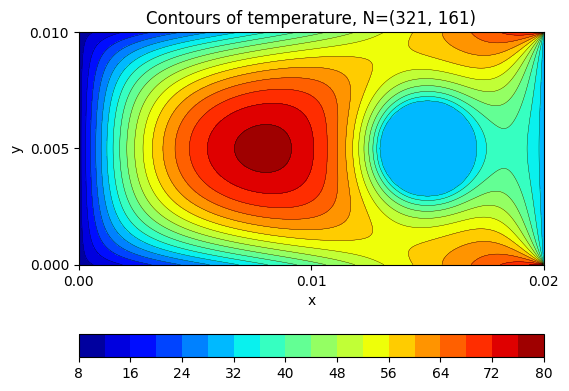

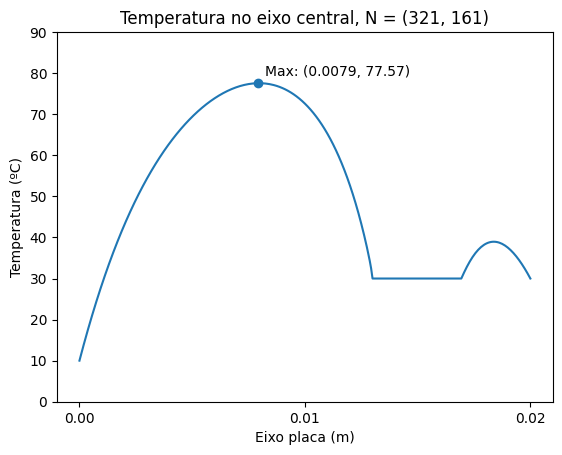

In [11]:
analise_regiao_circular = thermal.Thermal_P2(config = config, method = "sparse")
analise_regiao_circular.run(print_info = True, plot = True)

##### O quarto estudo estende o caso da região circular, analisando o efeito de diferentes temperaturas impostas nessa região sobre o comportamento global do sistema.

In [ ]:
analise_k_variavel = thermal.Thermal_P3(config = config, method = "sparse")
analise_k_variavel.run(plot = True)

##### O quarto estudo estende o caso da região circular, analisando o efeito de diferentes temperaturas impostas nessa região sobre o comportamento global do sistema.

In [ ]:
analise_regiao_circular_varias_temps = thermal.Thermal_P4(config = config, method = "sparse")
analise_regiao_circular_varias_temps.run(print_info = True, plot = True)

##### No quinto estudo, exploramos a linearidade do sistema. A temperatura em um nó k pode ser expressa como combinação linear das condições de contorno:
#### Tk = a⋅Tc + b⋅Tr + c
##### onde Tc é a temperatura da região circular e Tr da borda direita. Os coeficientes a, b e c foram determinados numericamente.

In [ ]:
analise_linearidade = thermal.Thermal_P5(config=config, method="sparse")
analise_linearidade.run(print_info = True)

### Métodos iterativos

##### Neste estudo, comparamos os métodos iterativos de Jacobi e Gauss-Seidel, analisando o tempo de convergência em função do tamanho da malha e da tolerância adotada.

![Resultados 1 do método iterativo](resultados_p1_extra/tempoXsubdivisoes_1.png)

![Resultados 2 do método iterativo](resultados_p1_extra/tempoXsubdivisoes_2.png)

![Resultados 3 do método iterativo](resultados_p1_extra/tempoXtolerancia.png)


##### A animação abaixo ilustra o processo de convergência dos métodos iterativos ao longo das iterações.

In [ ]:
from IPython.display import Video
Video("resultados_p1_extra/Animacao_Termica.mp4", width=600)

##### Por fim, investigamos qual deve ser a temperatura na região circular para que a temperatura máxima da placa atinja um valor desejado Tmax.


In [ ]:
test_P3_extra = thermal.Thermal_P3_Extra(config = config)
test_P3_extra.run(print_info = True, plot=False)